# 1 Data Exploration

In [3]:
# 1.1 Setup and load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data_path = "../data/raw/WQD.xlsx"

df = pd.read_excel(
    data_path,
    sheet_name="Final_Data"
)

df = df.rename(columns={
    "Temp": "temperature",
    "Turbidity (cm)": "turbidity",
    "DO(mg/L)": "dissolved_oxygen",
    "BOD (mg/L)": "bod",
    "CO2": "co2",
    "pH`": "ph",
    "Alkalinity (mg L-1 )": "alkalinity",
    "Hardness (mg L-1 )": "hardness",
    "Calcium (mg L-1 )": "calcium",
    "Ammonia (mg L-1 )": "ammonia",
    "Nitrite (mg L-1 )": "nitrite",
    "Phosphorus (mg L-1 )": "phosphorus",
    "H2S (mg L-1 )": "h2s",
    "Plankton (No. L-1)": "plankton",
    "Water Quality": "water_quality"
})

df.head()

,temperature,turbidity,dissolved_oxygen,bod,co2,ph,alkalinity,hardness,calcium,ammonia,nitrite,phosphorus,h2s,plankton,water_quality
0,67.448725,10.127148,0.208153,7.473607,10.181084,4.751657,218.364855,300.125080,337.178226,0.286054,4.355310,0.005984,0.066793,6069.624017,2
1,64.626666,94.015595,11.434463,10.859998,14.860521,3.085154,273.939692,8.426776,363.660740,0.096040,2.182753,0.004906,0.023428,250.995959,2
2,65.121842,90.653462,12.430865,12.809970,12.319980,9.648515,220.812730,11.726274,309.370934,0.974501,4.901760,0.006979,0.065041,7218.927473,2
3,1.640334,0.066344,10.963529,8.508023,12.955209,4.819988,266.571628,6.627655,8.180468,0.884865,3.571842,3.174473,0.026018,1230.062252,2
4,64.863434,2.119173,1.361736,13.335372,13.603197,10.244034,252.108000,339.891514,253.996871,0.801695,4.655898,3.854701,0.060995,1035.054820,2


## 1.2 Dataset overview


In [ ]:
# 1.2 Dataset overview
print("Shape:", df.shape)
print("\nMissing values:", df.isnull().sum().sum())
print("\nClass distribution:")
print(df["water_quality"].value_counts().sort_index())

df.info()

Shape: (4300, 15)

Missing values: 0

Class distribution:
water_quality
0    1400
1    1400
2    1500
Name: count, dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 4300 entries, 0 to 4299
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   temperature       4300 non-null   float64
 1   turbidity         4300 non-null   float64
 2   dissolved_oxygen  4300 non-null   float64
 3   bod               4300 non-null   float64
 4   co2               4300 non-null   float64
 5   ph                4300 non-null   float64
 6   alkalinity        4300 non-null   float64
 7   hardness          4300 non-null   float64
 8   calcium           4300 non-null   float64
 9   ammonia           4300 non-null   float64
 10  nitrite           4300 non-null   float64
 11  phosphorus        4300 non-null   float64
 12  h2s               4300 non-null   float64
 13  plankton          4300 non-null   float64
 14  water_quality     4

## 1.3 Descriptive statistics

In [ ]:

df.describe() # .T can transpose

,temperature,turbidity,dissolved_oxygen,bod,co2,ph,alkalinity,hardness,calcium,ammonia,nitrite,phosphorus,h2s,plankton,water_quality
count,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000
mean,25.695663,39.046681,5.300346,3.125079,6.375929,7.713468,93.717183,127.055476,84.871932,0.048269,0.642948,1.172749,0.016473,3805.510620,1.023256
std,9.670202,20.942726,1.832736,2.292060,2.831104,1.580282,68.949048,78.883091,75.718842,0.122886,0.903592,1.082648,0.011874,1208.547783,0.820996
min,0.194046,0.051424,0.133928,1.000621,0.001155,0.003944,25.012328,0.255805,0.018293,0.000001,0.000025,0.000128,0.000002,78.603733,0.000000
25%,19.775926,22.224140,3.978366,1.522077,5.048761,6.443019,40.422364,69.479620,23.745078,0.012750,0.010636,0.028355,0.010072,2956.020049,0.000000
50%,25.041849,30.205696,5.000754,2.236022,6.598076,7.743176,67.562607,111.063301,62.845419,0.026335,0.099908,0.975312,0.019049,3729.396476,1.000000
75%,30.277718,55.945735,6.521225,4.324578,8.241532,9.035251,132.834386,162.675648,115.596833,0.039016,1.166714,2.101317,0.019567,4555.089727,2.000000
max,84.251522,99.797743,14.970122,14.943006,14.984216,14.851195,299.913160,398.796550,399.321398,0.999300,4.989535,4.974457,0.099220,7460.415789,2.000000


## 1.4 Class distribution


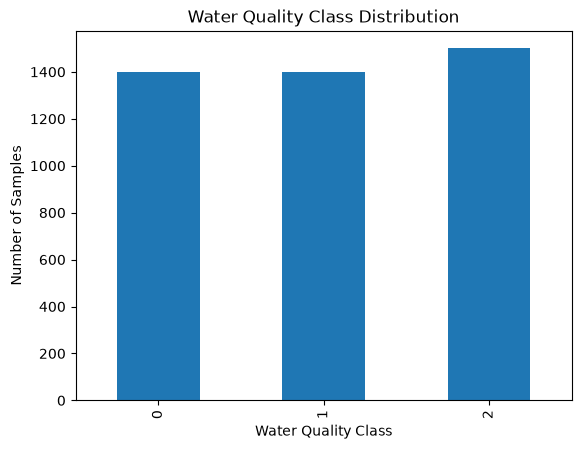

In [ ]:
class_counts = df["water_quality"].value_counts().sort_index()

class_counts.plot(kind="bar")
plt.title("Water Quality Class Distribution")
plt.xlabel("Water Quality Class")
plt.ylabel("Number of Samples")
plt.show()

The dataset is almost class-balanced, so severe class imbalance is unlikely to dominate the classification results.

## 1.5 Feature distributions


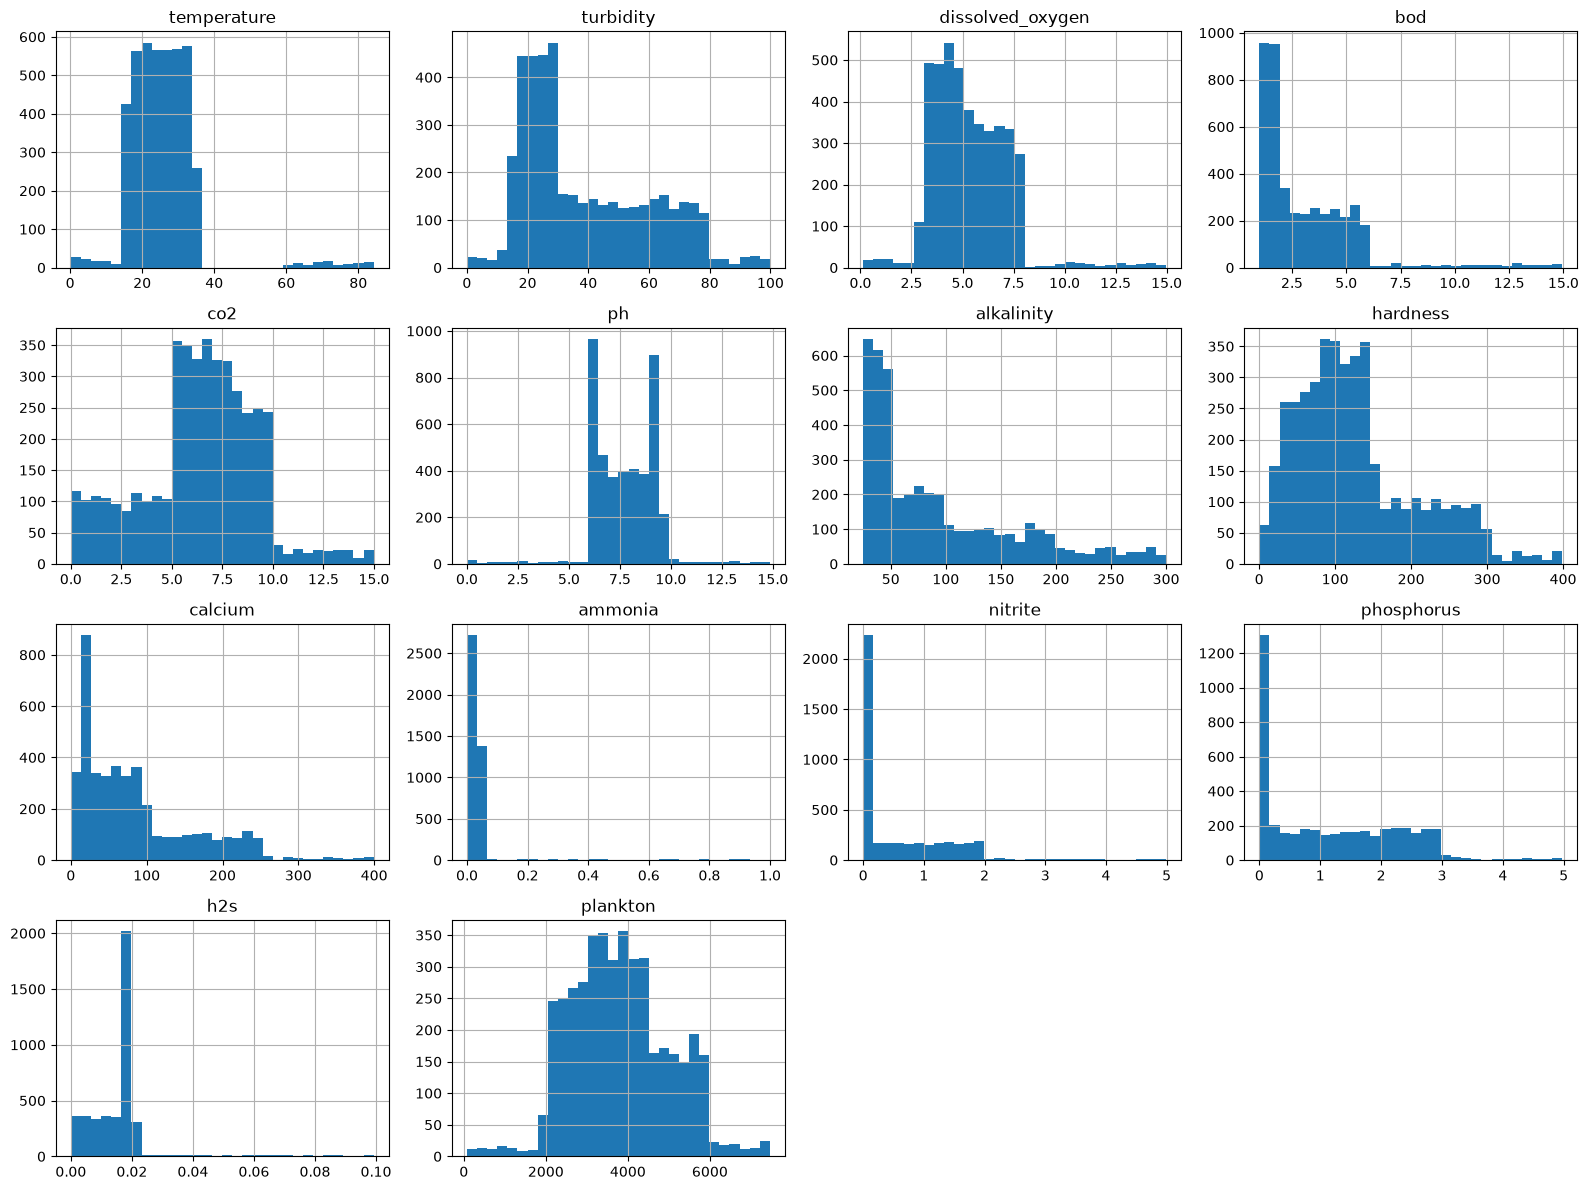

In [7]:
# 1.5 Feature distributions
features = df.drop(columns="water_quality").columns # remove target and get all features

df[features].hist(figsize=(16, 12), bins=30) # draw a histogram for each feature using 30 bins
plt.tight_layout() # automatically adjust spacing between subplots
plt.show()

## 1.6 Correlation Analysis


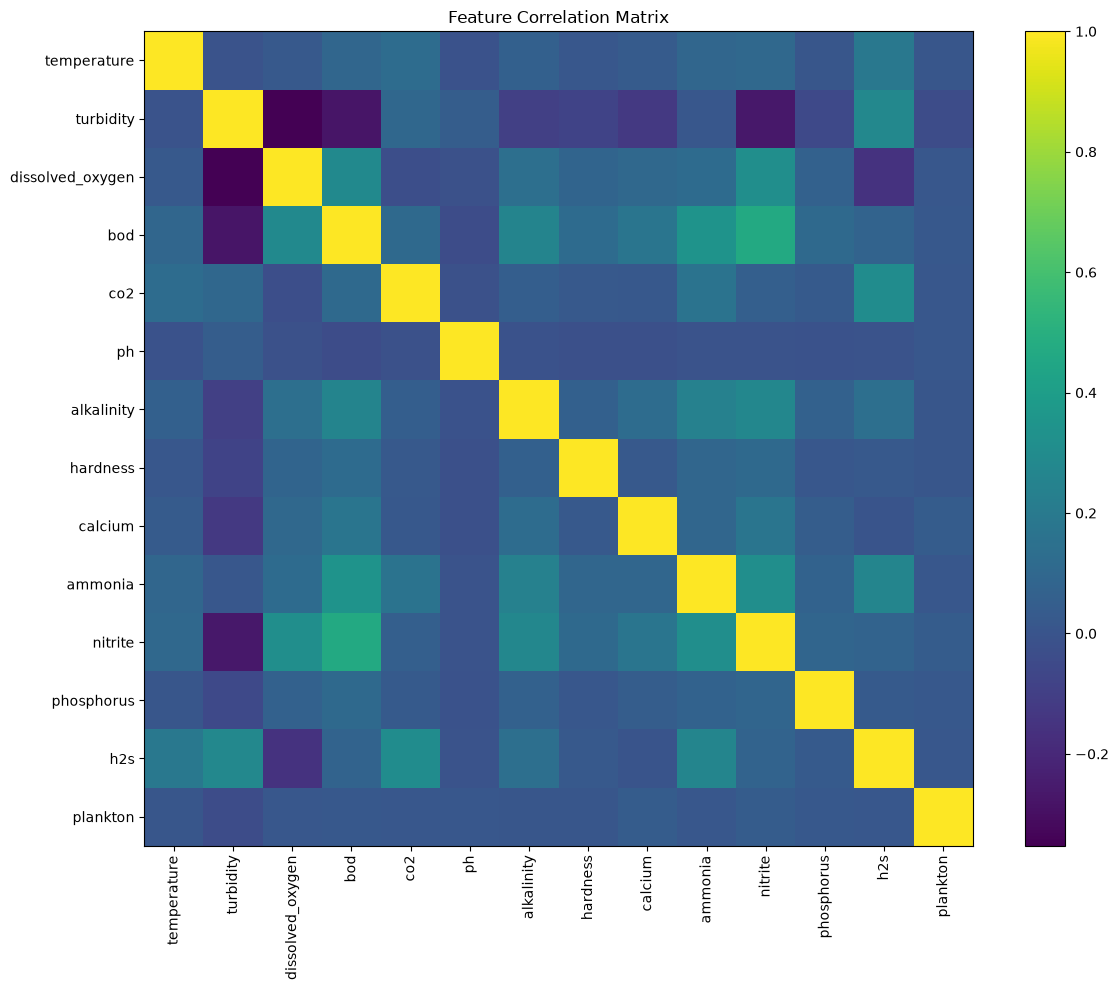

In [8]:
# 1.6 Correlation Analysis
features_df = df.drop(columns="water_quality")
corr = features_df.corr(numeric_only=True) # calculate the Pearson correlation between numerical columns

plt.figure(figsize=(12, 10))
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90) # rotate feature names to avoid overlapping
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar() # add a color bar
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

###  Key observations from data exploration

- Nitrite and BOD show a positive correlation.
- Dissolved oxygen and turbidity show a strong negative correlation.
- BOD and turbidity are negatively correlated.
- Nitrite and turbidity are also negatively correlated.

These relationships indicate possible redundancy or interaction among environmental variables, but correlation alone does not imply causation.

# 2 Classification Benchmark

## 2.1 Data Preparation


In [9]:
# 2.1 Data Preparation
X = df.drop(columns="water_quality")
y = df["water_quality"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (4300, 14)
Target shape: (4300,)


## 2.2 Train / Validation / Test Split


In [10]:
# 2.2 Train / Validation / Test Split
from sklearn.model_selection import train_test_split

# first split: 70% training, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# second split: divide the temporary set into validation and test sets
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (3010, 14)
Validation set: (645, 14)
Test set: (645, 14)


## 2.3 Feature Scaling for KNN


In [11]:
# 2.3 Feature Scaling for KNN
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


KNN is sensitive to feature scales because it uses distances to find neighbors. StandardScaler uses the training data’s mean and standard deviation to scale features, preventing larger-scale features from dominating. The same scaling is applied to validation and test data to avoid data leakage.

In [12]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="macro"),
        "Recall": recall_score(y_true, y_pred, average="macro"),
        "F1": f1_score(y_true, y_pred, average="macro")
    }

## 2.4 K-Nearest Neighbours


In [13]:
# 2.4 K-Nearest Neighbours
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_val_pred_knn = knn.predict(X_val_scaled)

knn_result = evaluate_model(
    "KNN",
    y_val,
    y_val_pred_knn
)

knn_result

{'Model': 'KNN',
 'Accuracy': 0.8744186046511628,
 'Precision': 0.8933841747646204,
 'Recall': 0.8798941798941798,
 'F1': 0.8693012278807345}

## 2.5 Decision Tree


In [14]:
# 2.5 Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

y_val_pred_dt = dt.predict(X_val)

dt_result = evaluate_model(
    "Decision Tree",
    y_val,
    y_val_pred_dt
)

dt_result

{'Model': 'Decision Tree',
 'Accuracy': 0.9953488372093023,
 'Precision': 0.9952755670809861,
 'Recall': 0.9955555555555556,
 'F1': 0.9953913190663406}

### 2.6 Random Forest


In [15]:
# 2.6 Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_val_pred_rf = rf.predict(X_val)

rf_result = evaluate_model(
    "Random Forest",
    y_val,
    y_val_pred_rf
)

rf_result

{'Model': 'Random Forest',
 'Accuracy': 0.9968992248062015,
 'Precision': 0.9968404423380726,
 'Recall': 0.997037037037037,
 'F1': 0.9969283734871621}

### 2.7 AdaBoost


In [16]:
# 2.7 AdaBoost
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

ada.fit(X_train, y_train)

y_val_pred_ada = ada.predict(X_val)

ada_result = evaluate_model(
    "AdaBoost",
    y_val,
    y_val_pred_ada
)

ada_result

# print("Predicted class distribution:")
# print(pd.Series(y_val_pred_ada).value_counts().sort_index())

# print("\nTrue class distribution:")
# print(y_val.value_counts().sort_index())

C:\Users\elodi\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


{'Model': 'AdaBoost',
 'Accuracy': 0.3488372093023256,
 'Precision': 0.11627906976744186,
 'Recall': 0.3333333333333333,
 'F1': 0.1724137931034483}

AdaBoost collapsed to predicting only class 2 on the validation set, resulting in very poor macro precision, recall, and F1. This suggests that the default AdaBoost configuration is not well suited to the current dataset.

## 2.8 Model Comparison


In [17]:
# 2.8 Model Comparison
results = pd.DataFrame([
    knn_result,
    dt_result,
    rf_result,
    ada_result
])

results

,Model,Accuracy,Precision,Recall,F1
0,KNN,0.874419,0.893384,0.879894,0.869301
1,Decision Tree,0.995349,0.995276,0.995556,0.995391
2,Random Forest,0.996899,0.996840,0.997037,0.996928
3,AdaBoost,0.348837,0.116279,0.333333,0.172414


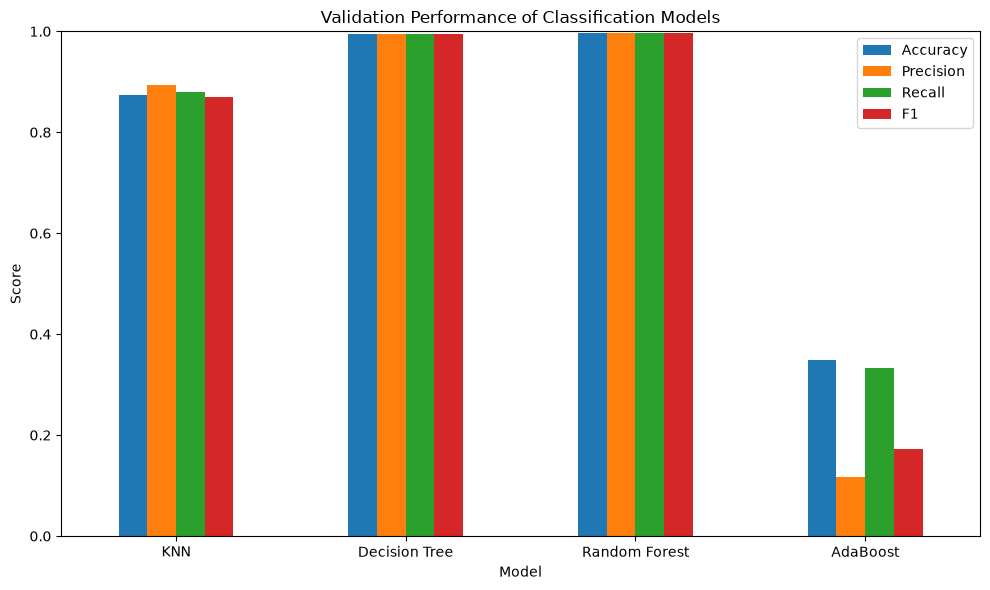

In [18]:
results.set_index("Model")[["Accuracy", "Precision", "Recall", "F1"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Validation Performance of Classification Models")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Key Observations from Classification Benchmark

- Random Forest achieved the best validation performance, with a F1 score of approximately 0.997.
- Decision Tree performed almost equally well, suggesting that the class boundaries may be strongly rule-based and well captured by tree models.
- KNN achieved lower performance than the tree-based models.
- AdaBoost collapsed to predicting only one class and performed poorly under the default configuration.

# 3. Feature Selection

## 3.1 Pearson Feature Selection


In [40]:
# 3.1 Pearson Feature Selection
feature_target_corr = df.corr(numeric_only=True)["water_quality"].drop("water_quality") # calculate the correlations between all features and  water_quality , excluding water_quality itself
feature_target_corr = feature_target_corr.abs().sort_values(ascending=False)

feature_target_corr

bod                 0.408549
nitrite             0.393259
alkalinity          0.356196
dissolved_oxygen    0.309709
turbidity           0.270976
ammonia             0.266592
calcium             0.169215
hardness            0.101322
phosphorus          0.094740
temperature         0.090868
co2                 0.064242
ph                  0.048118
h2s                 0.030509
plankton            0.022969
Name: water_quality, dtype: float64

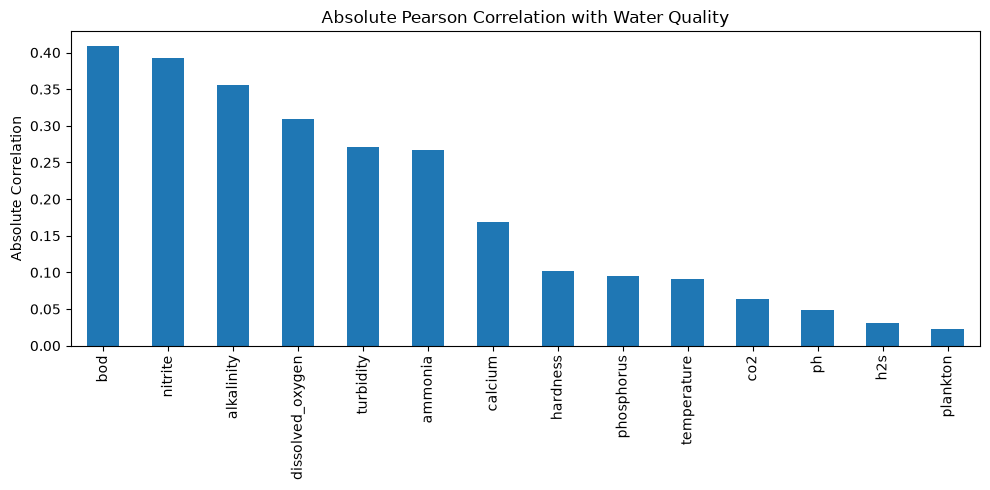

In [41]:
# 3.1.1 Draw Pearson Feature plot
feature_target_corr.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Absolute Pearson Correlation with Water Quality")
plt.ylabel("Absolute Correlation")
plt.tight_layout()
plt.show()

In [42]:
# 3.1.2 Get Top 5 features
top_features = feature_target_corr.head(5).index.tolist()

print("Top 5 features:")
print(top_features)

Top 5 features:
['bod', 'nitrite', 'alkalinity', 'dissolved_oxygen', 'turbidity']


In [43]:
# 3.1.3 Using Top 5 features train the model
X_train_top = X_train[top_features]
X_val_top = X_val[top_features]

rf_top = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_top.fit(X_train_top, y_train)

y_val_pred_rf_top = rf_top.predict(X_val_top)

rf_top_result = evaluate_model(
    "Random Forest + Pearson Top 5",
    y_val,
    y_val_pred_rf_top
)

rf_top_result

{'Model': 'Random Forest + Pearson Top 5',
 'Accuracy': 0.9069767441860465,
 'Precision': 0.9069767441860467,
 'Recall': 0.9084656084656085,
 'F1': 0.9074866310160429}

**randomforest using all features:**
{'Model': 'Random Forest',
 'Accuracy': 0.9968992248062015,
 'Precision': 0.9968404423380726,
 'Recall': 0.997037037037037,
 'F1': 0.9969283734871621}


**randomforest using first five correlated feature:**
{'Model': 'Random Forest + Pearson Top 5',
 'Accuracy': 0.9069767441860465,
 'Precision': 0.9069767441860467,
 'Recall': 0.9084656084656085,
 'F1': 0.9074866310160429}

### Key observation from comparison
 Using only the five features with the highest absolute Pearson correlation reduced the Random Forest macro F1 score from approximately 0.997 to 0.907.
This suggests that Pearson correlation alone does not capture all useful predictive information in the dataset. Some weakly correlated features may still contribute through nonlinear relationships or interactions with other variables.

In [44]:
# 3.1.4 compare model performance using different numbers of top features: [3, 5, 7, 10, 14]

top_k_results = []

for k in [3, 5, 7, 10, 14]:
    selected_features = feature_target_corr.head(k).index.tolist()

    rf_k = RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )

    rf_k.fit(X_train[selected_features], y_train)

    y_val_pred = rf_k.predict(X_val[selected_features])

    result = evaluate_model(
        f"Random Forest Top {k}",
        y_val,
        y_val_pred
    )

    result["Num Features"] = k
    top_k_results.append(result)

top_k_results_df = pd.DataFrame(top_k_results)

top_k_results_df

,Model,Accuracy,Precision,Recall,F1,Num Features
0,Random Forest Top 3,0.782946,0.779628,0.787937,0.778113,3
1,Random Forest Top 5,0.906977,0.906977,0.908466,0.907487,5
2,Random Forest Top 7,0.911628,0.911832,0.912910,0.912249,7
3,Random Forest Top 10,0.953488,0.953500,0.954392,0.953783,10
4,Random Forest Top 14,0.995349,0.995345,0.995450,0.995394,14


### Key Observations from Pearson Feature Selection

- Model performance improved as more Pearson-ranked features were included.
- Using only the top 3 features resulted in a substantial drop in performance.
- Increasing from 5 to 7 features produced only a small improvement.
- Performance improved more clearly when 10 features were used.
- The full 14-feature model still achieved the best validation performance.

These results suggest that Pearson correlation alone is not sufficient to identify all useful features for Random Forest. Some features with weaker individual linear correlation may still provide useful nonlinear or interaction effects.

## 3.2 PCA

In [45]:
# 3.2 PCA
from sklearn.decomposition import PCA

pca_full = PCA()

pca_full.fit(X_train_scaled)

explained_variance = pca_full.explained_variance_ratio_

explained_variance

array([0.18073307, 0.12598377, 0.07404273, 0.07161741, 0.07042091,
       0.06932263, 0.06787476, 0.06363368, 0.05966842, 0.05362262,
       0.04709968, 0.04190123, 0.03740117, 0.03667792])

The explained variance is distributed across many principal components rather than being concentrated in a small number of components. This suggests that PCA may provide only limited dimensionality reduction for this dataset.

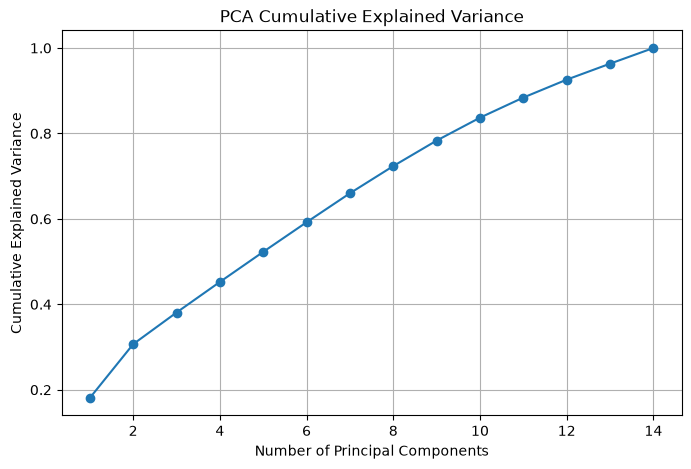

In [46]:
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.grid(True)
plt.show()

In [47]:
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print("Number of components required for 95% variance:", n_components_95)

Number of components required for 95% variance: 13


In [48]:
pca = PCA(n_components=n_components_95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original feature count:", X_train.shape[1])
print("PCA component count:", X_train_pca.shape[1])

Original feature count: 14
PCA component count: 13


In [49]:
rf_pca = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_pca.fit(X_train_pca, y_train)

y_val_pred_rf_pca = rf_pca.predict(X_val_pca)

rf_pca_result = evaluate_model(
    "Random Forest + PCA",
    y_val,
    y_val_pred_rf_pca
)

rf_pca_result

{'Model': 'Random Forest + PCA',
 'Accuracy': 0.937984496124031,
 'Precision': 0.9382980384958474,
 'Recall': 0.939047619047619,
 'F1': 0.938505515734712}

### Key Observation from PCA

PCA reduced the original 14 features to 13 principal components while retaining 95% of the variance. However, the Random Forest macro F1 score decreased from approximately 0.997 to 0.939.

This suggests that PCA is not very effective for this dataset. It provides little dimensionality reduction and also reduces classification performance. One possible reason is that PCA preserves overall variance without considering the target labels, so it may not preserve the most discriminative information for water-quality classification.

## 3.3 Genetic Algorithm Feature Selection

In [50]:
# 3.3 Genetic Algorithm Feature Selection
feature_names = X_train.columns.tolist()

print("Number of features:", len(feature_names))
print(feature_names)

Number of features: 14
['temperature', 'turbidity', 'dissolved_oxygen', 'bod', 'co2', 'ph', 'alkalinity', 'hardness', 'calcium', 'ammonia', 'nitrite', 'phosphorus', 'h2s', 'plankton']


In [51]:
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier

def evaluate_individual(individual):
    selected_features = [
        feature_names[i]
        for i, bit in enumerate(individual)
        if bit == 1
    ]

    # avoid empty feature subset
    if len(selected_features) == 0:
        return 0.0

    model = RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )

    model.fit(
        X_train[selected_features],
        y_train
    )

    y_pred = model.predict(
        X_val[selected_features]
    )

    score = f1_score(
        y_val,
        y_pred,
        average="macro"
    )

    return score

In [52]:
import random

POP_SIZE = 30
N_GENERATIONS = 20
MUTATION_RATE = 0.1
CROSSOVER_RATE = 0.8

def create_individual():
    return [
        random.randint(0, 1)
        for _ in range(len(feature_names))
    ]

population = [
    create_individual()
    for _ in range(POP_SIZE)
]

def tournament_selection(population, fitness_scores, tournament_size=3):
    candidates = random.sample(
        list(zip(population, fitness_scores)),
        tournament_size
    )

    candidates.sort(
        key=lambda x: x[1],
        reverse=True
    )

    return candidates[0][0].copy()

def crossover(parent1, parent2):
    if random.random() > CROSSOVER_RATE:
        return parent1.copy(), parent2.copy()

    point = random.randint(
        1,
        len(parent1) - 1
    )

    child1 = parent1[:point] + parent2[point:]
    child2 = parent2[:point] + parent1[point:]

    return child1, child2

def mutate(individual):
    for i in range(len(individual)):
        if random.random() < MUTATION_RATE:
            individual[i] = 1 - individual[i]

    return individual

In [53]:
best_individual = None
best_fitness = -1

for generation in range(N_GENERATIONS):

    fitness_scores = [
        evaluate_individual(individual)
        for individual in population
    ]

    generation_best_index = np.argmax(fitness_scores)
    generation_best_fitness = fitness_scores[generation_best_index]

    if generation_best_fitness > best_fitness:
        best_fitness = generation_best_fitness
        best_individual = population[generation_best_index].copy()

    print(
        f"Generation {generation + 1}: "
        f"Best F1 = {generation_best_fitness:.4f}"
    )

    new_population = []

    while len(new_population) < POP_SIZE:

        parent1 = tournament_selection(
            population,
            fitness_scores
        )

        parent2 = tournament_selection(
            population,
            fitness_scores
        )

        child1, child2 = crossover(
            parent1,
            parent2
        )

        child1 = mutate(child1)
        child2 = mutate(child2)

        new_population.extend([
            child1,
            child2
        ])

    population = new_population[:POP_SIZE]

Generation 1: Best F1 = 0.9969
Generation 2: Best F1 = 0.9939
Generation 3: Best F1 = 0.9969
Generation 4: Best F1 = 0.9954
Generation 5: Best F1 = 0.9969
Generation 6: Best F1 = 0.9954
Generation 7: Best F1 = 0.9969
Generation 8: Best F1 = 0.9969
Generation 9: Best F1 = 0.9969
Generation 10: Best F1 = 0.9969
Generation 11: Best F1 = 0.9969
Generation 12: Best F1 = 0.9969
Generation 13: Best F1 = 0.9969
Generation 14: Best F1 = 0.9969
Generation 15: Best F1 = 0.9969


KeyboardInterrupt: 

In [ ]:
ga_selected_features = [
    feature_names[i]
    for i, bit in enumerate(best_individual)
    if bit == 1
]

print("Best validation F1:", best_fitness)
print("Number of selected features:", len(ga_selected_features))
print("Selected features:")
print(ga_selected_features)

Best validation F1: 0.9969283734871621
Number of selected features: 11
Selected features:
['temperature', 'turbidity', 'dissolved_oxygen', 'bod', 'co2', 'ph', 'hardness', 'calcium', 'ammonia', 'nitrite', 'phosphorus']


### Key Observation

The Genetic Algorithm selected 11 of the 14 features,and macro F1 score stayed almost the same at 0.997.

The removed features were alkalinity, H2S, and plankton, which means these three features may not add much extra value for this model.

## 3.4 Feature Selection Comparison

In [ ]:
feature_selection_results = pd.DataFrame([
    {
        "Method": "All Features",
        "Num Features": 14,
        "F1": rf_result["F1"]
    },
    {
        "Method": "Pearson Top 5",
        "Num Features": 5,
        "F1": top_k_results_df.loc[
            top_k_results_df["Num Features"] == 5,
            "F1"
        ].values[0]
    },
    {
        "Method": "Pearson Top 7",
        "Num Features": 7,
        "F1": top_k_results_df.loc[
            top_k_results_df["Num Features"] == 7,
            "F1"
        ].values[0]
    },
    {
        "Method": "Pearson Top 10",
        "Num Features": 10,
        "F1": top_k_results_df.loc[
            top_k_results_df["Num Features"] == 10,
            "F1"
        ].values[0]
    },
    {
        "Method": "PCA",
        "Num Features": n_components_95,
        "F1": rf_pca_result["F1"]
    },
    {
        "Method": "Genetic Algorithm",
        "Num Features": len(ga_selected_features),
        "F1": best_fitness
    }
])

feature_selection_results

,Method,Num Features,F1
0,All Features,14,0.996928
1,Pearson Top 5,5,0.907487
2,Pearson Top 7,7,0.912249
3,Pearson Top 10,10,0.953783
4,PCA,13,0.938506
5,Genetic Algorithm,11,0.996928


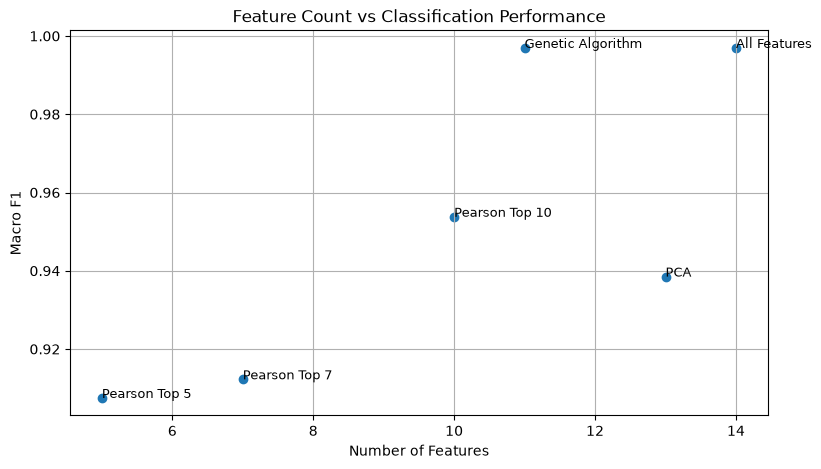

In [ ]:
plt.figure(figsize=(9, 5))

plt.scatter(
    feature_selection_results["Num Features"],
    feature_selection_results["F1"]
)

for _, row in feature_selection_results.iterrows():
    plt.text(
        row["Num Features"],
        row["F1"],
        row["Method"],
        fontsize=9
    )

plt.xlabel("Number of Features")
plt.ylabel("Macro F1")
plt.title("Feature Count vs Classification Performance")
plt.grid(True)
plt.show()

### Key Observations from Feature Selection

- The Genetic Algorithm achieved almost the same macro F1 score as the full-feature model. It reduced the number of features from 14 to 11.
- Pearson-based feature selection caused a larger drop in performance.
- PCA used 13 components but still performed worse than the Genetic Algorithm.
- Overall, the Genetic Algorithm gave the best balance between feature reduction and classification performance.

## 3.6 NSGA-II Feature Selection

NSGA-II is used to optimise two objectives at the same time:

1. Maximise classification performance.
2. Minimise the number of selected features.

This allows us to explore the trade-off between model performance and feature complexity.

minimise:
1 - F1 and feature_ratio

In [ ]:
POP_SIZE = 20
N_GENERATIONS = 10
CROSSOVER_RATE = 0.8
MUTATION_RATE = 0.2

def evaluate_nsga2_individual(individual):
    selected_features = [
        feature_names[i]
        for i, bit in enumerate(individual)
        if bit == 1
    ]

    if len(selected_features) == 0:
        return 1.0, 1.0

    model = RandomForestClassifier(
        n_estimators=30,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train[selected_features],
        y_train
    )

    y_pred = model.predict(
        X_val[selected_features]
    )

    f1 = f1_score(
        y_val,
        y_pred,
        average="macro"
    )

    classification_error = 1 - f1
    feature_ratio = len(selected_features) / len(feature_names)

    return classification_error, feature_ratio

In [ ]:
from deap import base, creator, tools

# define two objectives to minimise
creator.create(
    "FitnessMin",
    base.Fitness,
    weights=(-1.0, -1.0) # -1 means minimise: 1 - F1 and feature_ratio
)

# define  an individual as a list with fitness values
creator.create(
    "Individual",
    list,
    fitness=creator.FitnessMin
)

#create a toolbox to store the genetic algorithm operations
toolbox = base.Toolbox()

#Generate a random bit: 1 = select the feature, 0 = exclude i
toolbox.register(
    "attr_bool",
    random.randint,
    0,
    1
)
# Create an individual with one bit per feature
toolbox.register(
    "individual",
    tools.initRepeat,
    creator.Individual,
    toolbox.attr_bool,
    n=len(feature_names)
)

# Create a population as a list of individuals
toolbox.register(
    "population",
    tools.initRepeat,
    list,
    toolbox.individual
)

toolbox.register(
    "evaluate",
    evaluate_nsga2_individual
)

# crossover
toolbox.register(
    "crossover",
    tools.cxOnePoint
)

# mutation
toolbox.register(
    "mutate",
    tools.mutFlipBit,
    indpb=0.1
)

# Use NSGA-II to select individuals based on both objectives and diversity
# Keep different compromise solutions to avoid having all the selected individuals being pretty much the same.
toolbox.register(
    "select",
    tools.selNSGA2
)

# initial population
population = toolbox.population(n=POP_SIZE)

# Evaluate each individual's selected feature subset
for individual in population:
    individual.fitness.values = toolbox.evaluate(individual)

# Apply NSGA-II selection and assign crowding distances for tournaments
# The non-dominated sorting determines which layer should be retained first; the crowding distance helps in making choices within the same layer. Maintain various compromise solutions to prevent all the selected individuals from being too similar.
population = toolbox.select(
    population,
    len(population)
)

for generation in range(N_GENERATIONS):

    #select parents using dominance and crowding distance
    offspring = tools.selTournamentDCD(
        population,
        len(population)
    )

    #copy the selected parents so the original population stays unchanged
    offspring = [
        toolbox.clone(ind)
        for ind in offspring
    ]

    for i in range(0, len(offspring), 2):

        if random.random() < CROSSOVER_RATE:
            toolbox.crossover(
                offspring[i],
                offspring[i + 1]
            )

        toolbox.mutate(offspring[i])
        toolbox.mutate(offspring[i + 1])

        del offspring[i].fitness.values
        del offspring[i + 1].fitness.values

    invalid_individuals = [
        ind for ind in offspring
        if not ind.fitness.valid
    ]

    # recalculate fitness values for these offspring
    for individual in invalid_individuals:
        individual.fitness.values = toolbox.evaluate(individual)

    # select the next generation from parents and offspring
    population = toolbox.select(
        population + offspring,
        POP_SIZE
    )

    print(f"Generation {generation + 1} completed")

Generation 1 completed
Generation 2 completed
Generation 3 completed
Generation 4 completed
Generation 5 completed
Generation 6 completed


In [57]:
pareto_front = tools.sortNondominated(
    population,
    len(population),
    first_front_only=True
)[0]

pareto_results = []

for individual in pareto_front:

    selected_features = [
        feature_names[i]
        for i, bit in enumerate(individual)
        if bit == 1
    ]

    error, feature_ratio = individual.fitness.values

    pareto_results.append({
        "F1": 1 - error,
        "Num Features": len(selected_features),
        "Features": selected_features
    })

pareto_df = pd.DataFrame(pareto_results)

pareto_df.sort_values(
    by="Num Features"
)

,F1,Num Features,Features
4,0.691812,2,"[h2s, plankton]"
5,0.834154,3,"[turbidity, co2, hardness]"
2,0.938388,4,"[turbidity, dissolved_oxygen, bod, co2]"
0,0.990771,5,"[temperature, turbidity, dissolved_oxygen, bod..."
1,0.990771,5,"[temperature, turbidity, dissolved_oxygen, bod..."
3,0.995391,6,"[temperature, turbidity, dissolved_oxygen, bod..."


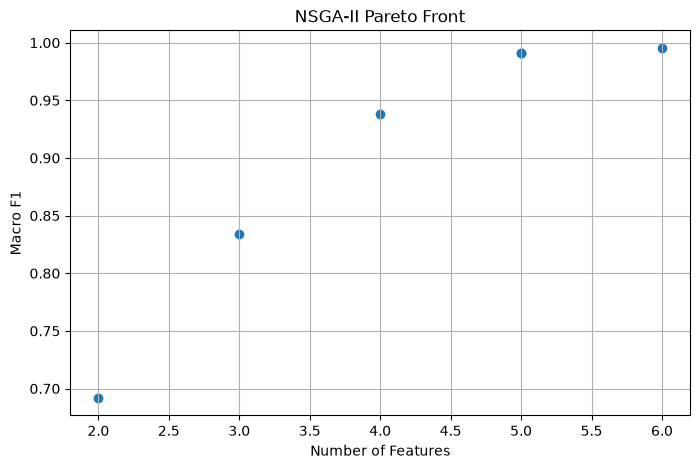

In [58]:
plt.figure(figsize=(8, 5))

plt.scatter(
    pareto_df["Num Features"],
    pareto_df["F1"]
)

plt.xlabel("Number of Features")
plt.ylabel("Macro F1")
plt.title("NSGA-II Pareto Front")
plt.grid(True)
plt.show()

NSGA-II has identified some "worthy feature combinations"
Then we took these combinations out and re-trained and validated them using Random Forest separately.

In [59]:
rf_pareto_results = []

for _, row in pareto_df.iterrows():
    selected_features = row["Features"]

    rf = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(
        X_train[selected_features],
        y_train
    )

    y_pred = rf.predict(
        X_val[selected_features]
    )

    rf_f1 = f1_score(
        y_val,
        y_pred,
        average="macro"
    )

    rf_pareto_results.append({
        "Num Features": len(selected_features),
        "Search F1": row["F1"],
        "Random Forest F1": rf_f1,
        "Features": selected_features
    })

rf_pareto_df = pd.DataFrame(rf_pareto_results)

rf_pareto_df.sort_values("Num Features")

,Num Features,Search F1,Random Forest F1,Features
4,2,0.691812,0.697650,"[h2s, plankton]"
5,3,0.834154,0.839540,"[turbidity, co2, hardness]"
2,4,0.938388,0.939944,"[turbidity, dissolved_oxygen, bod, co2]"
0,5,0.990771,0.987702,"[temperature, turbidity, dissolved_oxygen, bod..."
1,5,0.990771,0.987702,"[temperature, turbidity, dissolved_oxygen, bod..."
3,6,0.995391,0.996928,"[temperature, turbidity, dissolved_oxygen, bod..."


### Key Observations from NSGA-II

NSGA-II found several trade-off solutions between feature count and classification performance.

The 6-feature solution achieved a search macro F1 score of about 0.995.

The 5-feature solution also performed well, with a search F1 score of about 0.991.

This suggests that 6 features provide a very good balance between model performance and feature complexity.

When the selected feature subsets were re-evaluated with Random Forest, the 6-feature solution achieved a macro F1 score of about 0.997.

### Summary of Feature Selection

Pearson correlation and PCA reduced the feature space but caused a noticeable drop in classification performance.

The Genetic Algorithm reduced the number of features from 14 to 11 while keeping the macro F1 score close to 0.997.

NSGA-II identified a strong trade-off solution using 6 features, with a search F1 score of about 0.995. When this feature subset was re-evaluated using Random Forest, the macro F1 score was about 0.997.

Overall, evolutionary feature selection performed better than Pearson-based selection and PCA for this dataset.